In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving online+retail+ii.zip to online+retail+ii.zip


In [3]:
import os

print(os.listdir())

['.config', 'online+retail+ii.zip', 'sample_data']


In [4]:
import zipfile
zip_file_path = "online+retail+ii.zip"
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(".") # Extract to current directory

file_path = "online_retail_II.xlsx" # This file should now exist

excel_file = pd.ExcelFile(file_path)

print(excel_file.sheet_names)

['Year 2009-2010', 'Year 2010-2011']


In [5]:
df_2009_2010 = pd.read_excel(
    file_path,
    sheet_name="Year 2009-2010"
)

df_2010_2011 = pd.read_excel(
    file_path,
    sheet_name="Year 2010-2011"
)

In [6]:
df = pd.concat(
    [df_2009_2010, df_2010_2011],
    ignore_index=True
)

print(df.shape)

(1067371, 8)


In [7]:
file_path = "online_retail_II.xlsx"

df_2009_2010 = pd.read_excel(
    file_path,
    sheet_name="Year 2009-2010"
)

df_2010_2011 = pd.read_excel(
    file_path,
    sheet_name="Year 2010-2011"
)

df = pd.concat(
    [df_2009_2010, df_2010_2011],
    ignore_index=True
)

In [8]:
df_raw = df.copy()

print("Original shape:", df_raw.shape)

Original shape: (1067371, 8)


In [9]:
df.columns.tolist()

['Invoice',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'Price',
 'Customer ID',
 'Country']

In [10]:
df.columns = [
    'Invoice',
    'StockCode',
    'Description',
    'Quantity',
    'InvoiceDate',
    'Price',
    'CustomerID',
    'Country'
]

In [11]:
df.columns.tolist()

['Invoice',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'Price',
 'CustomerID',
 'Country']

In [12]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   CustomerID   824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [13]:
df['InvoiceDate'] = pd.to_datetime(
    df['InvoiceDate'],
    errors='coerce'
)

In [14]:
df['Quantity'] = pd.to_numeric(
    df['Quantity'],
    errors='coerce'
)

In [15]:
df['Price'] = pd.to_numeric(
    df['Price'],
    errors='coerce'
)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   CustomerID   824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [17]:
print("Total rows:", len(df))
print("Missing CustomerID:", df['CustomerID'].isna().sum())
print("Available CustomerID:", df['CustomerID'].notna().sum())

Total rows: 1067371
Missing CustomerID: 243007
Available CustomerID: 824364


In [18]:
df_clean = df.dropna(subset=['CustomerID']).copy()

In [19]:
print("Rows after removing missing CustomerID:", len(df_clean))
print("Missing CustomerID:", df_clean['CustomerID'].isna().sum())

Rows after removing missing CustomerID: 824364
Missing CustomerID: 0


In [20]:
cancelled_mask = df_clean['Invoice'].astype(str).str.startswith('C')

print("Cancelled transactions:", cancelled_mask.sum())
print("Normal transactions:", (~cancelled_mask).sum())

Cancelled transactions: 18744
Normal transactions: 805620


In [21]:
df_clean = df_clean[~cancelled_mask].copy()

In [22]:
print("Rows after removing cancellations:", len(df_clean))
print(
    "Cancelled transactions remaining:",
    df_clean['Invoice'].astype(str).str.startswith('C').sum()
)

Rows after removing cancellations: 805620
Cancelled transactions remaining: 0


In [23]:
print("Minimum Quantity:", df_clean['Quantity'].min())
print("Negative Quantity:", (df_clean['Quantity'] < 0).sum())
print("Zero Quantity:", (df_clean['Quantity'] == 0).sum())
print("Positive Quantity:", (df_clean['Quantity'] > 0).sum())

Minimum Quantity: 1
Negative Quantity: 0
Zero Quantity: 0
Positive Quantity: 805620


In [24]:
print("Minimum Price:", df_clean['Price'].min())
print("Maximum Price:", df_clean['Price'].max())
print("Zero Price:", (df_clean['Price'] == 0).sum())
print("Negative Price:", (df_clean['Price'] < 0).sum())
print("Positive Price:", (df_clean['Price'] > 0).sum())

Minimum Price: 0.0
Maximum Price: 10953.5
Zero Price: 71
Negative Price: 0
Positive Price: 805549


In [25]:
df_clean = df_clean[df_clean['Price'] > 0].copy()


In [26]:
print("Rows after removing zero-price transactions:", len(df_clean))
print("Zero Price remaining:", (df_clean['Price'] == 0).sum())
print("Negative Price remaining:", (df_clean['Price'] < 0).sum())

Rows after removing zero-price transactions: 805549
Zero Price remaining: 0
Negative Price remaining: 0


In [27]:
print("Duplicate rows:", df_clean.duplicated().sum())

Duplicate rows: 26124


In [28]:
df_clean = df_clean.drop_duplicates().copy()

In [29]:
print("Rows after removing duplicates:", len(df_clean))
print("Duplicate rows remaining:", df_clean.duplicated().sum())

Rows after removing duplicates: 779425
Duplicate rows remaining: 0


In [30]:
print("Missing InvoiceDate:", df_clean['InvoiceDate'].isna().sum())
print("Minimum InvoiceDate:", df_clean['InvoiceDate'].min())
print("Maximum InvoiceDate:", df_clean['InvoiceDate'].max())

Missing InvoiceDate: 0
Minimum InvoiceDate: 2009-12-01 07:45:00
Maximum InvoiceDate: 2011-12-09 12:50:00


In [31]:
print("Missing InvoiceDate:", df_clean['InvoiceDate'].isna().sum())
print("Minimum InvoiceDate:", df_clean['InvoiceDate'].min())
print("Maximum InvoiceDate:", df_clean['InvoiceDate'].max())

Missing InvoiceDate: 0
Minimum InvoiceDate: 2009-12-01 07:45:00
Maximum InvoiceDate: 2011-12-09 12:50:00


In [32]:
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['Price']

In [33]:
print(df_clean[['Quantity', 'Price', 'TotalAmount']].head())

   Quantity  Price  TotalAmount
0        12   6.95         83.4
1        12   6.75         81.0
2        12   6.75         81.0
3        48   2.10        100.8
4        24   1.25         30.0


In [34]:
print("========== FINAL CLEANING CHECK ==========")

print("Rows:", len(df_clean))
print("Columns:", len(df_clean.columns))

print("Missing CustomerID:", df_clean['CustomerID'].isna().sum())
print("Missing InvoiceDate:", df_clean['InvoiceDate'].isna().sum())

print("Negative Quantity:", (df_clean['Quantity'] < 0).sum())
print("Zero Quantity:", (df_clean['Quantity'] == 0).sum())

print("Non-positive Price:", (df_clean['Price'] <= 0).sum())

print(
    "Cancelled Invoices:",
    df_clean['Invoice'].astype(str).str.startswith('C').sum()
)

print("Duplicate Rows:", df_clean.duplicated().sum())

print("Missing TotalAmount:", df_clean['TotalAmount'].isna().sum())

========== FINAL CLEANING CHECK ==========
Rows: 779425
Columns: 9
Missing CustomerID: 0
Missing InvoiceDate: 0
Negative Quantity: 0
Zero Quantity: 0
Non-positive Price: 0
Cancelled Invoices: 0
Duplicate Rows: 0
Missing TotalAmount: 0


In [35]:
latest_date = df_clean['InvoiceDate'].max()

print("Latest Transaction Date:", latest_date)

Latest Transaction Date: 2011-12-09 12:50:00


In [36]:
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Latest Transaction:", df_clean['InvoiceDate'].max())
print("Reference Date:", reference_date)

Latest Transaction: 2011-12-09 12:50:00
Reference Date: 2011-12-10 12:50:00


In [37]:
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': 'max'
}).reset_index()

rfm.rename(
    columns={'InvoiceDate': 'LastPurchaseDate'},
    inplace=True
)

rfm['Recency'] = (
    reference_date - rfm['LastPurchaseDate']
).dt.days

rfm.head()

,CustomerID,LastPurchaseDate,Recency
0,12346.0,2011-01-18 10:01:00,326
1,12347.0,2011-12-07 15:52:00,2
2,12348.0,2011-09-25 13:13:00,75
3,12349.0,2011-11-21 09:51:00,19
4,12350.0,2011-02-02 16:01:00,310


In [38]:
frequency = df_clean.groupby('CustomerID').agg({
    'Invoice': 'nunique'
}).reset_index()

frequency.rename(
    columns={'Invoice': 'Frequency'},
    inplace=True
)

frequency.head()

,CustomerID,Frequency
0,12346.0,12
1,12347.0,8
2,12348.0,5
3,12349.0,4
4,12350.0,1


In [39]:
print("Total customers:", frequency['CustomerID'].nunique())
print("Minimum Frequency:", frequency['Frequency'].min())
print("Maximum Frequency:", frequency['Frequency'].max())

Total customers: 5878
Minimum Frequency: 1
Maximum Frequency: 398


In [40]:
monetary = df_clean.groupby('CustomerID').agg({
    'TotalAmount': 'sum'
}).reset_index()

monetary.rename(columns={
    'TotalAmount': 'Monetary'
}, inplace=True)

monetary.head()

,CustomerID,Monetary
0,12346.0,77556.46
1,12347.0,4921.53
2,12348.0,2019.40
3,12349.0,4428.69
4,12350.0,334.40


In [41]:
print("Minimum Monetary:", monetary['Monetary'].min())
print("Maximum Monetary:", monetary['Monetary'].max())
print("Average Monetary:", monetary['Monetary'].mean())

Minimum Monetary: 2.95
Maximum Monetary: 580987.04
Average Monetary: 2955.9040945899965


In [42]:
rfm_final = rfm[['CustomerID', 'Recency']].merge(
    frequency[['CustomerID', 'Frequency']],
    on='CustomerID',
    how='inner'
).merge(
    monetary[['CustomerID', 'Monetary']],
    on='CustomerID',
    how='inner'
)

rfm_final.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,4921.53
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


In [43]:
print("RFM shape:", rfm_final.shape)
print("Missing values:")
print(rfm_final.isnull().sum())

print("\nRFM summary:")
print(rfm_final[['Recency', 'Frequency', 'Monetary']].describe())

RFM shape: (5878, 4)
Missing values:
CustomerID    0
Recency       0
Frequency     0
Monetary      0
dtype: int64

RFM summary:
           Recency    Frequency       Monetary
count  5878.000000  5878.000000    5878.000000
mean    201.331916     6.289384    2955.904095
std     209.338707    13.009406   14440.852688
min       1.000000     1.000000       2.950000
25%      26.000000     1.000000     342.280000
50%      96.000000     3.000000     867.740000
75%     380.000000     7.000000    2248.305000
max     739.000000   398.000000  580987.040000


In [44]:
# Recency score: lower recency = better score
rfm_final['R_Score'] = pd.qcut(
    rfm_final['Recency'].rank(method='first'),
    q=5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

# Frequency score: higher frequency = better score
rfm_final['F_Score'] = pd.qcut(
    rfm_final['Frequency'].rank(method='first'),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Monetary score: higher spending = better score
rfm_final['M_Score'] = pd.qcut(
    rfm_final['Monetary'].rank(method='first'),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm_final['RFM_Score'] = (
    rfm_final['R_Score'].astype(str) +
    rfm_final['F_Score'].astype(str) +
    rfm_final['M_Score'].astype(str)
)

rfm_final.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346.0,326,12,77556.46,2,5,5,255
1,12347.0,2,8,4921.53,5,4,5,545
2,12348.0,75,5,2019.40,3,4,4,344
3,12349.0,19,4,4428.69,5,3,5,535
4,12350.0,310,1,334.40,2,1,2,212


In [45]:
print(rfm_final[
    ['R_Score', 'F_Score', 'M_Score']
].describe())

print("\nRFM score examples:")
print(rfm_final[
    ['CustomerID', 'Recency', 'Frequency', 'Monetary',
     'R_Score', 'F_Score', 'M_Score', 'RFM_Score']
].head(10))

           R_Score      F_Score      M_Score
count  5878.000000  5878.000000  5878.000000
mean      3.000000     3.000000     3.000000
std       1.414454     1.414454     1.414454
min       1.000000     1.000000     1.000000
25%       2.000000     2.000000     2.000000
50%       3.000000     3.000000     3.000000
75%       4.000000     4.000000     4.000000
max       5.000000     5.000000     5.000000

RFM score examples:
   CustomerID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0     12346.0      326         12  77556.46        2        5        5   
1     12347.0        2          8   4921.53        5        4        5   
2     12348.0       75          5   2019.40        3        4        4   
3     12349.0       19          4   4428.69        5        3        5   
4     12350.0      310          1    334.40        2        1        2   
5     12351.0      375          1    300.93        2        1        2   
6     12352.0       36         10   2849.84        4    

In [46]:
def assign_segment(row):
    r = row['R_Score']
    f = row['F_Score']
    m = row['M_Score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'

    elif r >= 3 and f >= 4:
        return 'Loyal Customers'

    elif r >= 4 and f <= 3:
        return 'Potential Loyalists'

    elif r <= 2 and f >= 4 and m >= 4:
        return 'At Risk High Value'

    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost Customers'

    elif r <= 2:
        return 'At Risk'

    else:
        return 'Need Attention'


rfm_final['Segment'] = rfm_final.apply(assign_segment, axis=1)

rfm_final.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346.0,326,12,77556.46,2,5,5,255,At Risk High Value
1,12347.0,2,8,4921.53,5,4,5,545,Champions
2,12348.0,75,5,2019.40,3,4,4,344,Loyal Customers
3,12349.0,19,4,4428.69,5,3,5,535,Potential Loyalists
4,12350.0,310,1,334.40,2,1,2,212,Lost Customers


In [47]:
segment_summary = rfm_final['Segment'].value_counts().reset_index()

segment_summary.columns = ['Segment', 'CustomerCount']

segment_summary['Percentage'] = (
    segment_summary['CustomerCount'] /
    len(rfm_final) * 100
).round(2)

segment_summary

,Segment,CustomerCount,Percentage
0,Champions,1289,21.93
1,Lost Customers,1282,21.81
2,Potential Loyalists,878,14.94
3,At Risk,846,14.39
4,Loyal Customers,708,12.04
5,Need Attention,652,11.09
6,At Risk High Value,223,3.79


In [48]:
segment_business_summary = rfm_final.groupby('Segment').agg(
    CustomerCount=('CustomerID', 'count'),
    AvgRecency=('Recency', 'mean'),
    AvgFrequency=('Frequency', 'mean'),
    AvgMonetary=('Monetary', 'mean'),
    TotalRevenue=('Monetary', 'sum')
).reset_index()

segment_business_summary = segment_business_summary.sort_values(
    by='TotalRevenue',
    ascending=False
)

segment_business_summary

,Segment,CustomerCount,AvgRecency,AvgFrequency,AvgMonetary,TotalRevenue
2,Champions,1289,19.719162,17.146625,9169.609678,1.181963e+07
4,Loyal Customers,708,83.933616,7.769774,2677.445445,1.895631e+06
1,At Risk High Value,223,342.295964,8.977578,4404.135345,9.821222e+05
0,At Risk,846,389.476359,2.916076,1110.479706,9.394658e+05
6,Potential Loyalists,878,26.364465,2.289294,990.802746,8.699248e+05
5,Need Attention,652,108.984663,2.096626,834.036722,5.437919e+05
3,Lost Customers,1282,466.888456,1.185647,252.918293,3.242413e+05


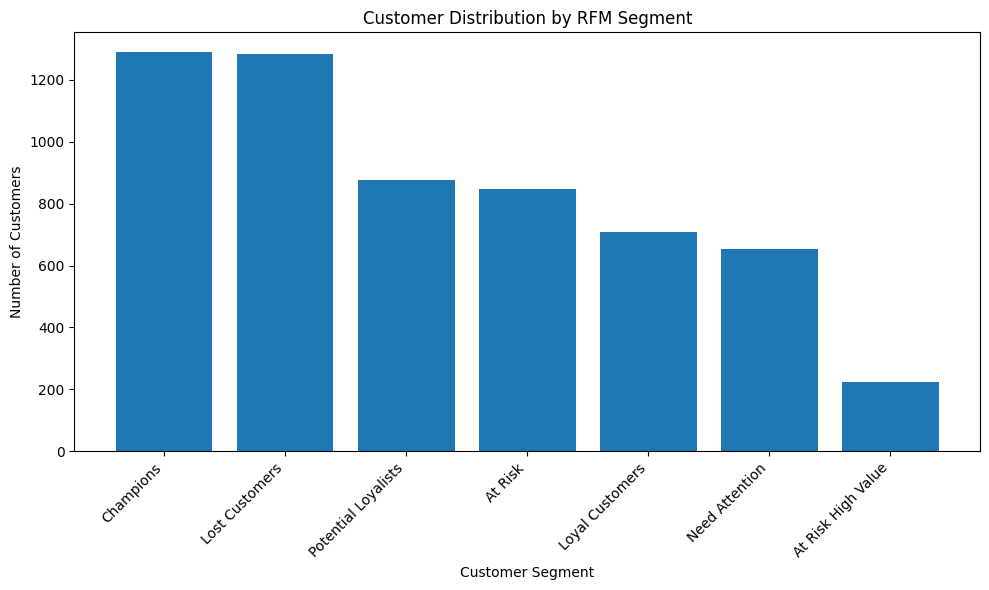

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    segment_summary['Segment'],
    segment_summary['CustomerCount']
)

plt.title('Customer Distribution by RFM Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

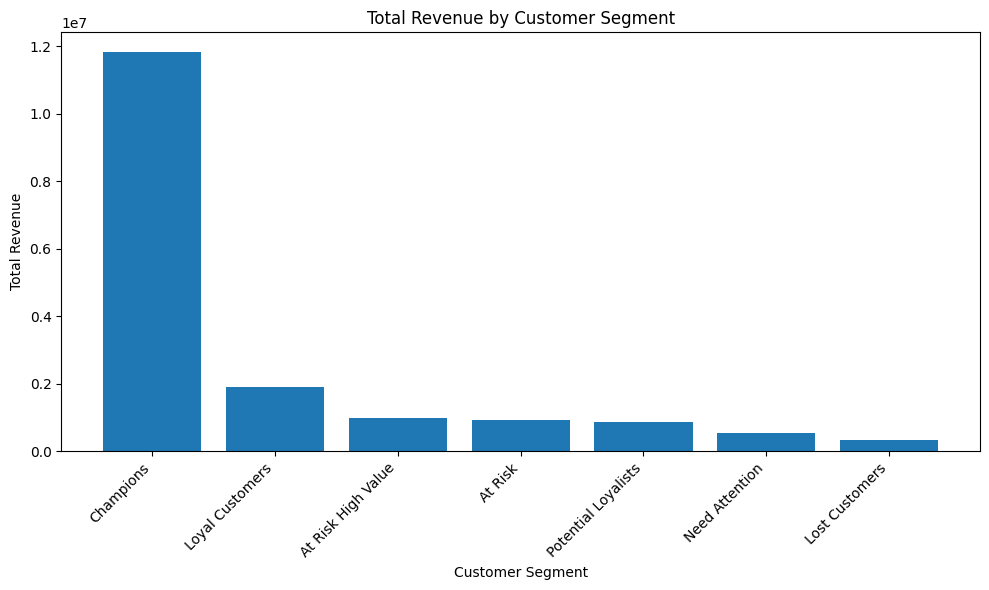

In [50]:
revenue_chart = segment_business_summary.sort_values(
    by='TotalRevenue',
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.bar(
    revenue_chart['Segment'],
    revenue_chart['TotalRevenue']
)

plt.title('Total Revenue by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [51]:
rfm_final.to_csv(
    'final_rfm_customer_segmentation.csv',
    index=False
)

print("Final RFM dataset saved successfully!")

Final RFM dataset saved successfully!


In [52]:
segment_business_summary.to_csv(
    'rfm_segment_business_summary.csv',
    index=False
)

segment_summary.to_csv(
    'rfm_segment_distribution.csv',
    index=False
)

print("All summary files saved successfully!")

All summary files saved successfully!


In [53]:
# Basic RFM validation

print("Total customers:", len(rfm_final))
print("\nMissing values:")
print(rfm_final.isnull().sum())

print("\nDuplicate customer IDs:")
print(rfm_final['CustomerID'].duplicated().sum())

print("\nRFM value ranges:")
print(rfm_final[['Recency', 'Frequency', 'Monetary']].describe())

Total customers: 5878

Missing values:
CustomerID    0
Recency       0
Frequency     0
Monetary      0
R_Score       0
F_Score       0
M_Score       0
RFM_Score     0
Segment       0
dtype: int64

Duplicate customer IDs:
0

RFM value ranges:
           Recency    Frequency       Monetary
count  5878.000000  5878.000000    5878.000000
mean    201.331916     6.289384    2955.904095
std     209.338707    13.009406   14440.852688
min       1.000000     1.000000       2.950000
25%      26.000000     1.000000     342.280000
50%      96.000000     3.000000     867.740000
75%     380.000000     7.000000    2248.305000
max     739.000000   398.000000  580987.040000


In [54]:
# Check segment distribution

segment_counts = rfm_final['Segment'].value_counts()

print("Customer Segment Distribution:")
print(segment_counts)

print("\nTotal customers across segments:", segment_counts.sum())

Customer Segment Distribution:
Segment
Champions              1289
Lost Customers         1282
Potential Loyalists     878
At Risk                 846
Loyal Customers         708
Need Attention          652
At Risk High Value      223
Name: count, dtype: int64

Total customers across segments: 5878


In [55]:
segment_percentage = (
    rfm_final['Segment']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

segment_percentage

,proportion
Segment,
Champions,21.93
Lost Customers,21.81
Potential Loyalists,14.94
At Risk,14.39
Loyal Customers,12.04
Need Attention,11.09
At Risk High Value,3.79


In [57]:
revenue_by_segment = (
    rfm_final.groupby('Segment')['Monetary']
    .agg(['count', 'sum', 'mean'])
    .sort_values('sum', ascending=False)
)

revenue_by_segment


,count,sum,mean
Segment,,,
Champions,1289,1.181963e+07,9169.609678
Loyal Customers,708,1.895631e+06,2677.445445
At Risk High Value,223,9.821222e+05,4404.135345
At Risk,846,9.394658e+05,1110.479706
Potential Loyalists,878,8.699248e+05,990.802746
Need Attention,652,5.437919e+05,834.036722
Lost Customers,1282,3.242413e+05,252.918293


In [56]:
print("Expected customers:", 5878)
print("Actual customers:", len(rfm_final))

print("\nExpected segment count:", 7)
print("Actual segments:", rfm_final['Segment'].nunique())

print("\nAll customers assigned to a segment:",
      rfm_final['Segment'].notna().all())

Expected customers: 5878
Actual customers: 5878

Expected segment count: 7
Actual segments: 7

All customers assigned to a segment: True


In [58]:
# ================================
# STEP 14A — DASHBOARD KPIs
# ================================

total_customers = rfm_final['CustomerID'].nunique()
total_revenue = rfm_final['Monetary'].sum()
avg_revenue = rfm_final['Monetary'].mean()
avg_frequency = rfm_final['Frequency'].mean()
avg_recency = rfm_final['Recency'].mean()

print("RFM DASHBOARD KPIs")
print("=" * 40)
print(f"Total Customers       : {total_customers:,}")
print(f"Total Revenue         : {total_revenue:,.2f}")
print(f"Average Revenue       : {avg_revenue:,.2f}")
print(f"Average Frequency     : {avg_frequency:,.2f}")
print(f"Average Recency       : {avg_recency:,.2f} days")

RFM DASHBOARD KPIs
Total Customers       : 5,878
Total Revenue         : 17,374,804.27
Average Revenue       : 2,955.90
Average Frequency     : 6.29
Average Recency       : 201.33 days


In [59]:
# Segment-level dashboard data

dashboard_summary = (
    rfm_final
    .groupby('Segment')
    .agg(
        Customers=('CustomerID', 'nunique'),
        Total_Revenue=('Monetary', 'sum'),
        Avg_Revenue=('Monetary', 'mean'),
        Avg_Frequency=('Frequency', 'mean'),
        Avg_Recency=('Recency', 'mean')
    )
    .reset_index()
)

dashboard_summary['Customer_%'] = (
    dashboard_summary['Customers'] /
    total_customers * 100
).round(2)

dashboard_summary['Revenue_%'] = (
    dashboard_summary['Total_Revenue'] /
    total_revenue * 100
).round(2)

dashboard_summary = dashboard_summary.sort_values(
    'Total_Revenue',
    ascending=False
)

dashboard_summary

,Segment,Customers,Total_Revenue,Avg_Revenue,Avg_Frequency,Avg_Recency,Customer_%,Revenue_%
2,Champions,1289,1.181963e+07,9169.609678,17.146625,19.719162,21.93,68.03
4,Loyal Customers,708,1.895631e+06,2677.445445,7.769774,83.933616,12.04,10.91
1,At Risk High Value,223,9.821222e+05,4404.135345,8.977578,342.295964,3.79,5.65
0,At Risk,846,9.394658e+05,1110.479706,2.916076,389.476359,14.39,5.41
6,Potential Loyalists,878,8.699248e+05,990.802746,2.289294,26.364465,14.94,5.01
5,Need Attention,652,5.437919e+05,834.036722,2.096626,108.984663,11.09,3.13
3,Lost Customers,1282,3.242413e+05,252.918293,1.185647,466.888456,21.81,1.87


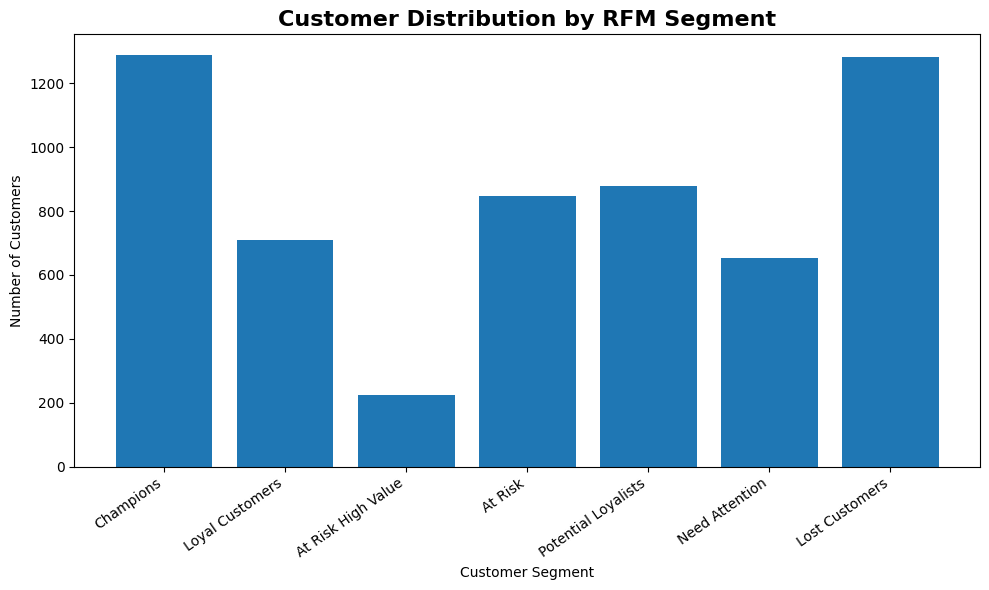

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    dashboard_summary['Segment'],
    dashboard_summary['Customers']
)

plt.title(
    'Customer Distribution by RFM Segment',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')

plt.xticks(rotation=35, ha='right')

plt.tight_layout()
plt.show()

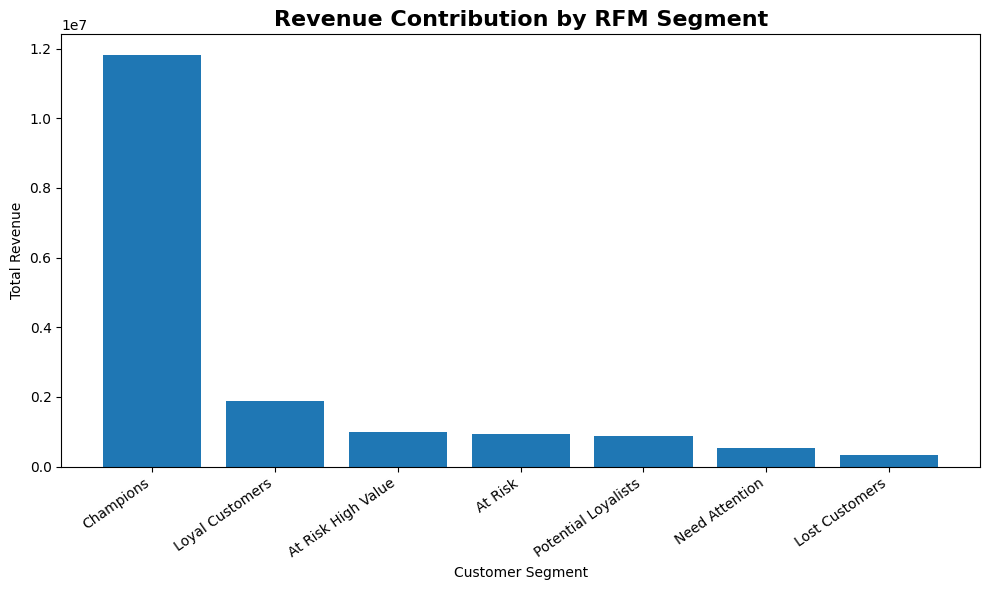

In [61]:
plt.figure(figsize=(10, 6))

plt.bar(
    dashboard_summary['Segment'],
    dashboard_summary['Total_Revenue']
)

plt.title(
    'Revenue Contribution by RFM Segment',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Customer Segment')
plt.ylabel('Total Revenue')

plt.xticks(rotation=35, ha='right')

plt.tight_layout()
plt.show()

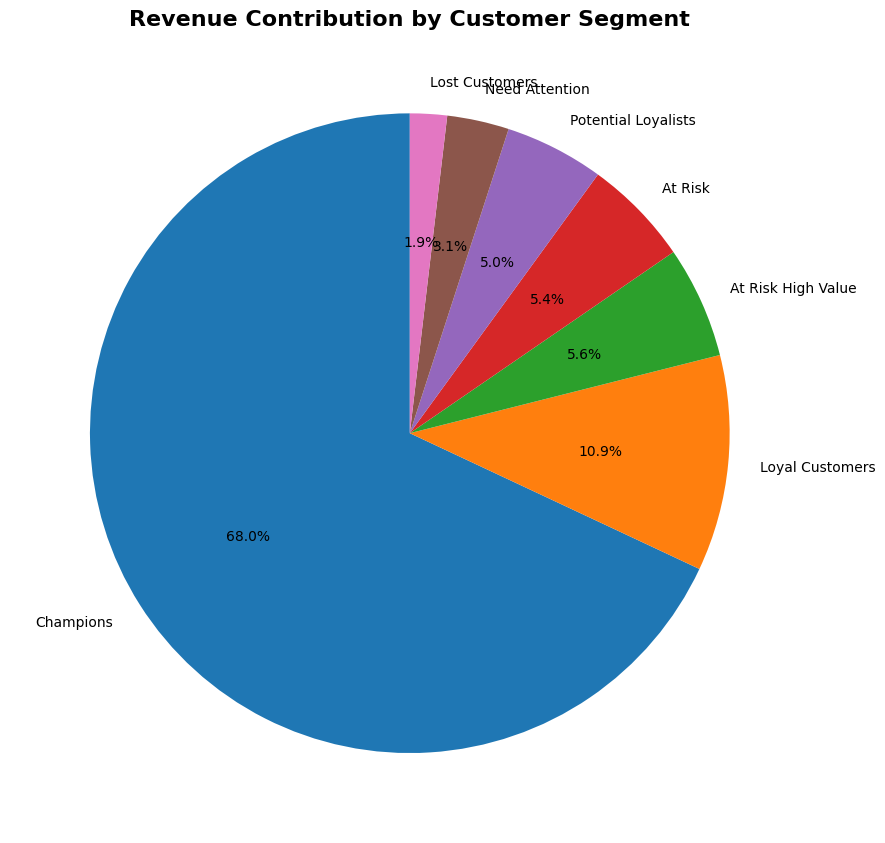

In [62]:
plt.figure(figsize=(9, 9))

plt.pie(
    dashboard_summary['Revenue_%'],
    labels=dashboard_summary['Segment'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title(
    'Revenue Contribution by Customer Segment',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

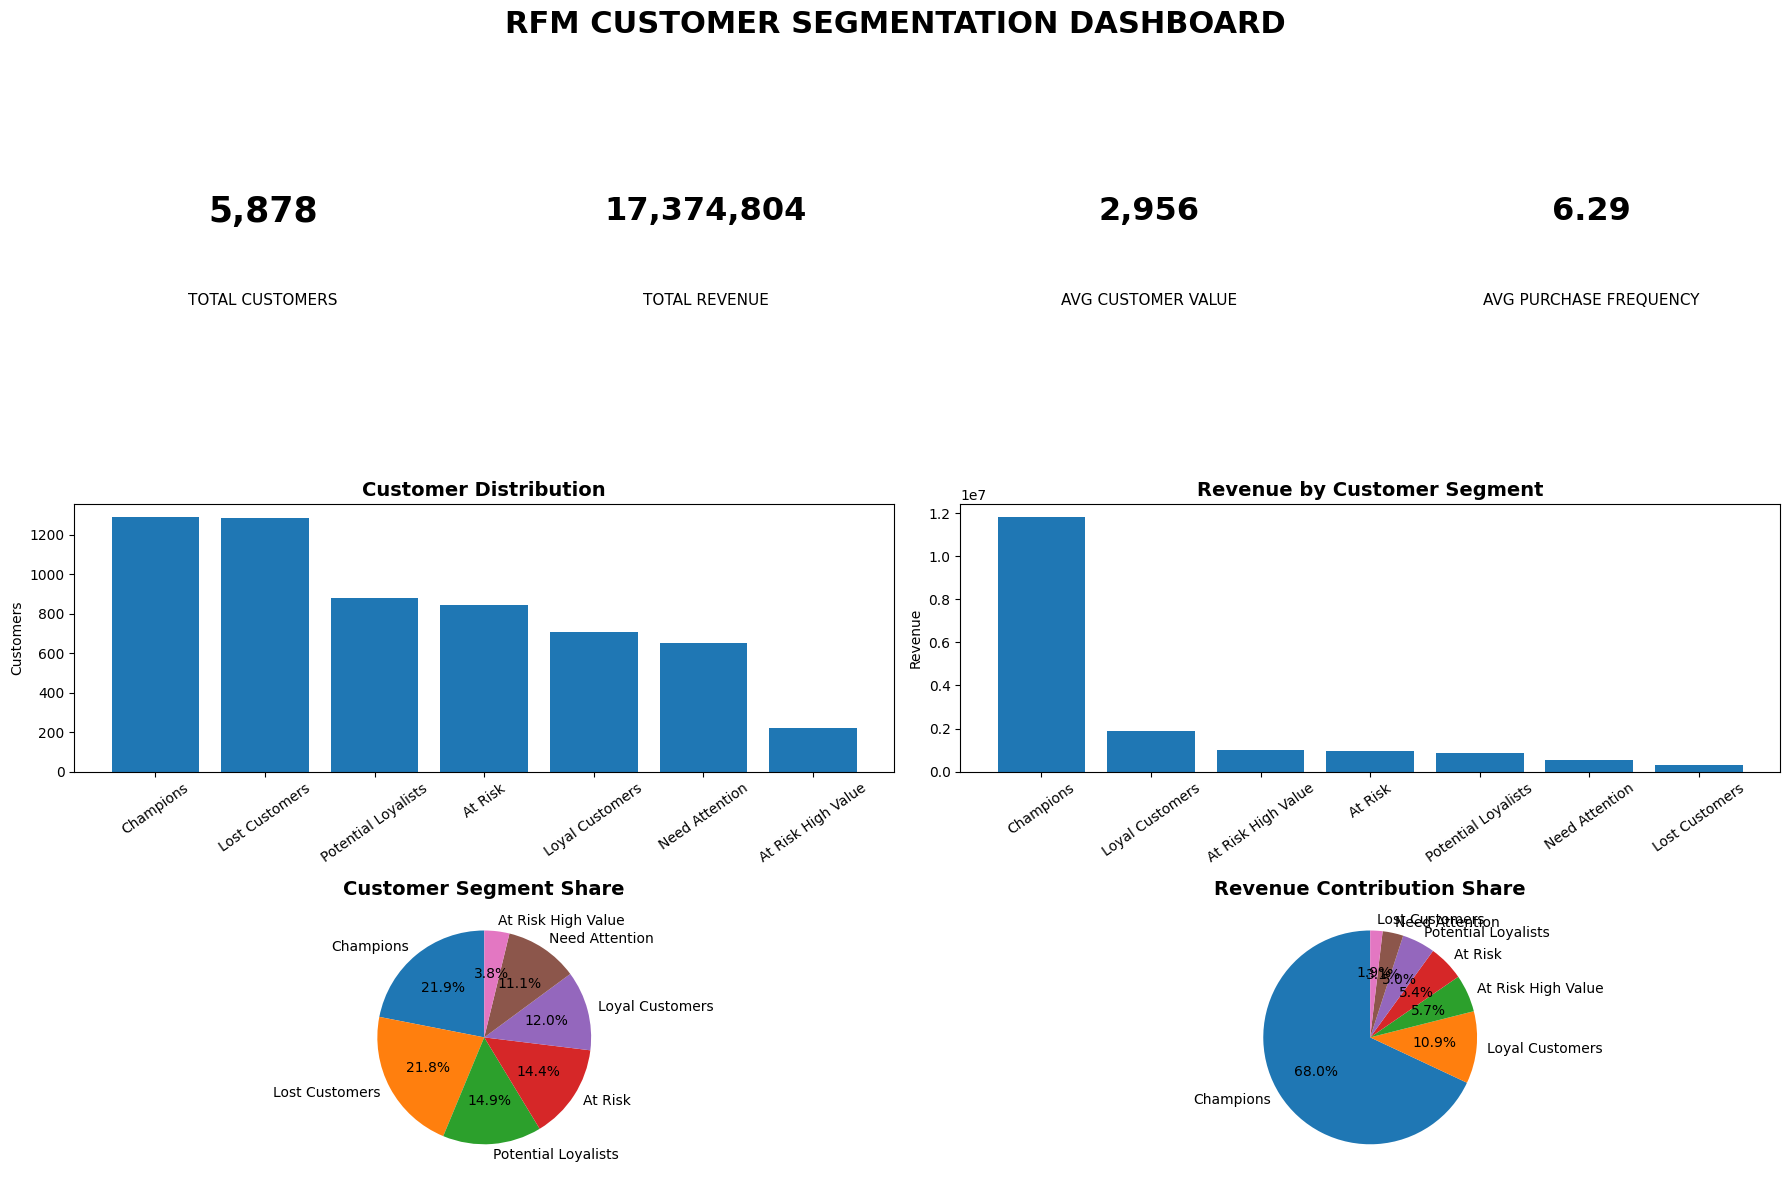

In [63]:
# ============================================================
# STEP 15 — PROFESSIONAL RFM CUSTOMER SEGMENTATION DASHBOARD
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1. Calculate KPIs
# -----------------------------

total_customers = rfm_final['CustomerID'].nunique()
total_revenue = rfm_final['Monetary'].sum()
avg_revenue = rfm_final['Monetary'].mean()
avg_frequency = rfm_final['Frequency'].mean()

# -----------------------------
# 2. Segment Summary
# -----------------------------

dashboard_summary = (
    rfm_final
    .groupby('Segment')
    .agg(
        Customers=('CustomerID', 'nunique'),
        Total_Revenue=('Monetary', 'sum'),
        Avg_Revenue=('Monetary', 'mean'),
        Avg_Frequency=('Frequency', 'mean'),
        Avg_Recency=('Recency', 'mean')
    )
    .reset_index()
)

dashboard_summary['Customer_%'] = (
    dashboard_summary['Customers'] / total_customers * 100
)

dashboard_summary['Revenue_%'] = (
    dashboard_summary['Total_Revenue'] / total_revenue * 100
)

# Sort for charts
customer_chart = dashboard_summary.sort_values(
    'Customers',
    ascending=False
)

revenue_chart = dashboard_summary.sort_values(
    'Total_Revenue',
    ascending=False
)

# -----------------------------
# 3. Create Dashboard
# -----------------------------

fig = plt.figure(figsize=(18, 12))

fig.suptitle(
    'RFM CUSTOMER SEGMENTATION DASHBOARD',
    fontsize=22,
    fontweight='bold',
    y=0.98
)

# ============================================================
# KPI 1 — Total Customers
# ============================================================

ax1 = plt.subplot2grid((3, 4), (0, 0))

ax1.text(
    0.5, 0.6,
    f'{total_customers:,}',
    ha='center',
    va='center',
    fontsize=25,
    fontweight='bold'
)

ax1.text(
    0.5, 0.25,
    'TOTAL CUSTOMERS',
    ha='center',
    fontsize=11
)

ax1.axis('off')


# ============================================================
# KPI 2 — Total Revenue
# ============================================================

ax2 = plt.subplot2grid((3, 4), (0, 1))

ax2.text(
    0.5, 0.6,
    f'{total_revenue:,.0f}',
    ha='center',
    va='center',
    fontsize=23,
    fontweight='bold'
)

ax2.text(
    0.5, 0.25,
    'TOTAL REVENUE',
    ha='center',
    fontsize=11
)

ax2.axis('off')


# ============================================================
# KPI 3 — Average Revenue
# ============================================================

ax3 = plt.subplot2grid((3, 4), (0, 2))

ax3.text(
    0.5, 0.6,
    f'{avg_revenue:,.0f}',
    ha='center',
    va='center',
    fontsize=23,
    fontweight='bold'
)

ax3.text(
    0.5, 0.25,
    'AVG CUSTOMER VALUE',
    ha='center',
    fontsize=11
)

ax3.axis('off')


# ============================================================
# KPI 4 — Average Frequency
# ============================================================

ax4 = plt.subplot2grid((3, 4), (0, 3))

ax4.text(
    0.5, 0.6,
    f'{avg_frequency:.2f}',
    ha='center',
    va='center',
    fontsize=23,
    fontweight='bold'
)

ax4.text(
    0.5, 0.25,
    'AVG PURCHASE FREQUENCY',
    ha='center',
    fontsize=11
)

ax4.axis('off')


# ============================================================
# CHART 1 — Customer Distribution
# ============================================================

ax5 = plt.subplot2grid((3, 4), (1, 0), colspan=2)

ax5.bar(
    customer_chart['Segment'],
    customer_chart['Customers']
)

ax5.set_title(
    'Customer Distribution',
    fontsize=14,
    fontweight='bold'
)

ax5.set_ylabel('Customers')

ax5.tick_params(axis='x', rotation=35)


# ============================================================
# CHART 2 — Revenue Contribution
# ============================================================

ax6 = plt.subplot2grid((3, 4), (1, 2), colspan=2)

ax6.bar(
    revenue_chart['Segment'],
    revenue_chart['Total_Revenue']
)

ax6.set_title(
    'Revenue by Customer Segment',
    fontsize=14,
    fontweight='bold'
)

ax6.set_ylabel('Revenue')

ax6.tick_params(axis='x', rotation=35)


# ============================================================
# CHART 3 — Customer %
# ============================================================

ax7 = plt.subplot2grid((3, 4), (2, 0), colspan=2)

ax7.pie(
    customer_chart['Customers'],
    labels=customer_chart['Segment'],
    autopct='%1.1f%%',
    startangle=90
)

ax7.set_title(
    'Customer Segment Share',
    fontsize=14,
    fontweight='bold'
)


# ============================================================
# CHART 4 — Revenue %
# ============================================================

ax8 = plt.subplot2grid((3, 4), (2, 2), colspan=2)

ax8.pie(
    revenue_chart['Total_Revenue'],
    labels=revenue_chart['Segment'],
    autopct='%1.1f%%',
    startangle=90
)

ax8.set_title(
    'Revenue Contribution Share',
    fontsize=14,
    fontweight='bold'
)


plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

In [64]:
# ============================================================
# STEP 16 — AUTOMATED BUSINESS INSIGHTS
# ============================================================

# Sort segments by revenue
revenue_rank = dashboard_summary.sort_values(
    'Total_Revenue',
    ascending=False
)

# Sort segments by customer count
customer_rank = dashboard_summary.sort_values(
    'Customers',
    ascending=False
)

# Highest revenue segment
highest_revenue_segment = revenue_rank.iloc[0]

# Largest customer segment
largest_customer_segment = customer_rank.iloc[0]

# High-value at-risk customers
high_value_risk = rfm_final[
    rfm_final['Segment'] == 'At Risk High Value'
]

# Lost customers
lost_customers = rfm_final[
    rfm_final['Segment'] == 'Lost Customers'
]

# Champions
champions = rfm_final[
    rfm_final['Segment'] == 'Champions'
]

print("=" * 70)
print("RFM BUSINESS INSIGHTS")
print("=" * 70)

print(
    f"\n1. Highest Revenue Segment:"
    f"\n   {highest_revenue_segment['Segment']}"
    f" contributes "
    f"{highest_revenue_segment['Revenue_%']:.2f}% of total revenue."
)

print(
    f"\n2. Largest Customer Segment:"
    f"\n   {largest_customer_segment['Segment']}"
    f" contains "
    f"{int(largest_customer_segment['Customers']):,} customers "
    f"({largest_customer_segment['Customer_%']:.2f}%)."
)

print(
    f"\n3. High-Value At-Risk Customers:"
    f"\n   {len(high_value_risk):,} customers are classified as "
    f"'At Risk High Value'."
)

print(
    f"\n4. Lost Customers:"
    f"\n   {len(lost_customers):,} customers are currently classified "
    f"as Lost Customers."
)

print(
    f"\n5. Champions:"
    f"\n   {len(champions):,} customers are classified as Champions."
)

print("\n" + "=" * 70)

RFM BUSINESS INSIGHTS

1. Highest Revenue Segment:
   Champions contributes 68.03% of total revenue.

2. Largest Customer Segment:
   Champions contains 1,289 customers (21.93%).

3. High-Value At-Risk Customers:
   223 customers are classified as 'At Risk High Value'.

4. Lost Customers:
   1,282 customers are currently classified as Lost Customers.

5. Champions:
   1,289 customers are classified as Champions.



In [65]:
# ============================================================
# HIGH-VALUE AT-RISK ANALYSIS
# ============================================================

high_value_risk_revenue = high_value_risk['Monetary'].sum()
champion_revenue = champions['Monetary'].sum()
lost_revenue = lost_customers['Monetary'].sum()

print("HIGH-VALUE CUSTOMER OPPORTUNITY")
print("=" * 50)

print(
    f"At Risk High Value Customers : {len(high_value_risk):,}"
)

print(
    f"Historical Revenue           : {high_value_risk_revenue:,.2f}"
)

print(
    f"Champion Revenue             : {champion_revenue:,.2f}"
)

print(
    f"Lost Customer Revenue        : {lost_revenue:,.2f}"
)

HIGH-VALUE CUSTOMER OPPORTUNITY
At Risk High Value Customers : 223
Historical Revenue           : 982,122.18
Champion Revenue             : 11,819,626.88
Lost Customer Revenue        : 324,241.25


In [66]:
# ============================================================
# STEP 16C — ACTIONABLE RECOMMENDATIONS
# ============================================================

recommendations = {
    'Champions':
        'Reward loyalty, provide VIP benefits, early access and premium offers.',

    'Loyal Customers':
        'Use cross-selling, upselling and loyalty rewards to increase value.',

    'Potential Loyalists':
        'Encourage repeat purchases through personalized recommendations and offers.',

    'At Risk High Value':
        'Prioritize personalized win-back campaigns and retention offers.',

    'At Risk':
        'Use targeted re-engagement campaigns and limited-time incentives.',

    'Need Attention':
        'Increase engagement through product discovery and personalized communication.',

    'Lost Customers':
        'Use low-cost reactivation campaigns and avoid excessive marketing spend.'
}

print("=" * 70)
print("SEGMENT-WISE RECOMMENDATIONS")
print("=" * 70)

for segment, action in recommendations.items():
    print(f"\n{segment}:")
    print(f"→ {action}")

SEGMENT-WISE RECOMMENDATIONS

Champions:
→ Reward loyalty, provide VIP benefits, early access and premium offers.

Loyal Customers:
→ Use cross-selling, upselling and loyalty rewards to increase value.

Potential Loyalists:
→ Encourage repeat purchases through personalized recommendations and offers.

At Risk High Value:
→ Prioritize personalized win-back campaigns and retention offers.

At Risk:
→ Use targeted re-engagement campaigns and limited-time incentives.

Need Attention:
→ Increase engagement through product discovery and personalized communication.

Lost Customers:
→ Use low-cost reactivation campaigns and avoid excessive marketing spend.


# Step 17: Final Project Summary

## Project Objective
The objective of this project is to segment customers based on their purchasing
behavior using RFM (Recency, Frequency, Monetary) analysis and derive actionable
business insights.

## RFM Metrics
- **Recency:** Number of days since the customer's most recent purchase.
- **Frequency:** Number of purchases made by the customer.
- **Monetary:** Total amount spent by the customer.

## Customer Segments
The analysis classified customers into seven segments:

1. Champions
2. Loyal Customers
3. Potential Loyalists
4. At Risk High Value
5. At Risk
6. Need Attention
7. Lost Customers

## Final Results
- Total Customers Analyzed: 5,878
- Customer Segments: 7
- All customers were successfully assigned to a segment.

## Key Business Insights
- Champions represent an important high-value customer group.
- At Risk High Value customers should receive priority retention efforts.
- Lost Customers represent an opportunity for selective reactivation campaigns.
- Customer count alone does not determine business value; revenue contribution
  varies significantly across customer segments.

## Business Recommendations
- **Champions:** Loyalty rewards, VIP benefits and exclusive offers.
- **Loyal Customers:** Cross-selling and upselling.
- **Potential Loyalists:** Encourage repeat purchases with personalized offers.
- **At Risk High Value:** Personalized retention and win-back campaigns.
- **At Risk:** Re-engagement campaigns and limited-time incentives.
- **Need Attention:** Personalized communication and engagement campaigns.
- **Lost Customers:** Low-cost and selective reactivation campaigns.

## Conclusion
RFM analysis successfully segmented 5,878 customers into seven behavioral groups.
The segmentation provides a data-driven framework for customer retention,
personalized marketing, reactivation strategies and customer value optimization.

In [67]:
# ==========================================
# STEP 18A — SAVE FINAL PROJECT OUTPUTS
# ==========================================

# Create output directory
import os

os.makedirs("rfm_project/outputs", exist_ok=True)
os.makedirs("rfm_project/visualizations", exist_ok=True)

# Save final RFM dataset
rfm_final.to_csv(
    "rfm_project/outputs/final_rfm_customer_segmentation.csv",
    index=False
)

# Save segment summary
dashboard_summary.to_csv(
    "rfm_project/outputs/rfm_segment_summary.csv",
    index=False
)

# Save business recommendations
recommendations_df = pd.DataFrame(
    list(recommendations.items()),
    columns=["Segment", "Recommended_Action"]
)

recommendations_df.to_csv(
    "rfm_project/outputs/rfm_business_recommendations.csv",
    index=False
)

print("All project output files saved successfully!")

All project output files saved successfully!


In [68]:
plt.savefig(
    "rfm_project/visualizations/rfm_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [69]:
plt.savefig(
    "rfm_project/visualizations/customer_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [70]:
plt.savefig(
    "rfm_project/visualizations/revenue_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [71]:
plt.savefig(
    "rfm_project/visualizations/revenue_contribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [72]:
requirements = """pandas
numpy
matplotlib
"""

with open(
    "rfm_project/requirements.txt",
    "w"
) as f:
    f.write(requirements)

print("requirements.txt created!")

requirements.txt created!


In [73]:
readme = """# RFM Customer Segmentation & Business Analytics

## Project Overview

This project uses RFM (Recency, Frequency, Monetary) analysis to segment
customers based on their purchasing behavior and identify actionable
business opportunities.

## Objectives

- Analyze customer purchasing behavior
- Calculate Recency, Frequency and Monetary metrics
- Develop customer segments
- Analyze revenue contribution
- Identify high-value and at-risk customers
- Develop segment-specific business recommendations

## Dataset

The analysis contains 5,878 customers.

## Methodology

Customer transaction data was transformed into customer-level RFM metrics:

- Recency — days since the customer's most recent purchase
- Frequency — number of purchases
- Monetary — total amount spent

Customers were then scored and classified into seven behavioral segments.

## Customer Segments

1. Champions
2. Loyal Customers
3. Potential Loyalists
4. At Risk High Value
5. At Risk
6. Need Attention
7. Lost Customers

## Dashboard

The project includes a dashboard showing:

- Total customers
- Total revenue
- Average customer value
- Average purchase frequency
- Customer distribution
- Revenue by segment
- Customer segment share
- Revenue contribution

## Key Insights

The analysis demonstrates that customer count and revenue contribution
are not necessarily proportional. High-value at-risk customers represent
an important retention opportunity, while lost customers can be targeted
through selective reactivation campaigns.

## Business Recommendations

Different customer segments should receive different marketing strategies,
including loyalty rewards, cross-selling, personalized retention campaigns,
re-engagement campaigns and selective reactivation.

## Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Google Colab

## Project Structure

rfm_project/
│
├── outputs/
│   ├── final_rfm_customer_segmentation.csv
│   ├── rfm_segment_summary.csv
│   └── rfm_business_recommendations.csv
│
├── visualizations/
│   ├── rfm_dashboard.png
│   ├── customer_distribution.png
│   ├── revenue_by_segment.png
│   └── revenue_contribution.png
│
├── requirements.txt
└── README.md
"""

with open(
    "rfm_project/README.md",
    "w"
) as f:
    f.write(readme)

print("README.md created!")

README.md created!


In [74]:
import os

for root, dirs, files in os.walk("rfm_project"):
    level = root.replace("rfm_project", "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    {file}")

rfm_project/
    README.md
    requirements.txt
    outputs/
        final_rfm_customer_segmentation.csv
        rfm_segment_summary.csv
        rfm_business_recommendations.csv
    visualizations/
        customer_distribution.png
        revenue_by_segment.png
        revenue_contribution.png
        rfm_dashboard.png


In [75]:
import shutil

shutil.make_archive(
    "RFM_Customer_Segmentation_Project",
    "zip",
    "rfm_project"
)

print("Project ZIP created successfully!")

Project ZIP created successfully!
